---
## Setup

In [3]:
import os
import tensorflow as tf
os.environ['TFHUB_MODEL_LOAD_FORMAT'] = 'COMPRESSED'

import IPython.display as display

import matplotlib.pyplot as plt
import matplotlib as mpl
mpl.rcParams['figure.figsize'] = (12,12)
mpl.rcParams['axes.grid'] = False

import numpy as np
import time
import PIL.Image
import functools

from tensorflow.keras.applications.convnext import ConvNeXtTiny, preprocess_input

from tensorflow.keras.preprocessing.image import load_img, img_to_array
from tensorflow.keras.models import Model

In [4]:
# Image Credits: Tensorflow Doc
content_path = "/content/bird.jpg"
style_path = tf.keras.utils.get_file(
  'style.jpg',
  'https://storage.googleapis.com/download.tensorflow.org/example_images/Vassily_Kandinsky%2C_1913_-_Composition_7.jpg')

In [5]:
def load_and_process_image(image_path):
    img = load_img(image_path, target_size=(330, 330))
    img = img_to_array(img)
    img = preprocess_input(img)
    img = tf.image.resize(img, (330, 330))

    img = tf.expand_dims(img, axis=0)

    return tf.cast(img, tf.float32)


def deprocess(img):
    img = img.copy()

    img[:, :, 0] += 103.939
    img[:, :, 1] += 116.779
    img[:, :, 2] += 123.68

    img = img[:, :, ::-1]
    img = np.clip(img, 0, 255).astype(np.uint8)
    return img

---
## Preprocess

In [6]:
def display_image(image):
    if len(image.shape) == 4:
        img = np.squeeze(image, axis=0)

    img = deprocess(img)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    plt.show()


def display_image(image):
    if len(image.shape) == 4:
        img = np.squeeze(image, axis=0)

    img = deprocess(img)

    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img)
    return

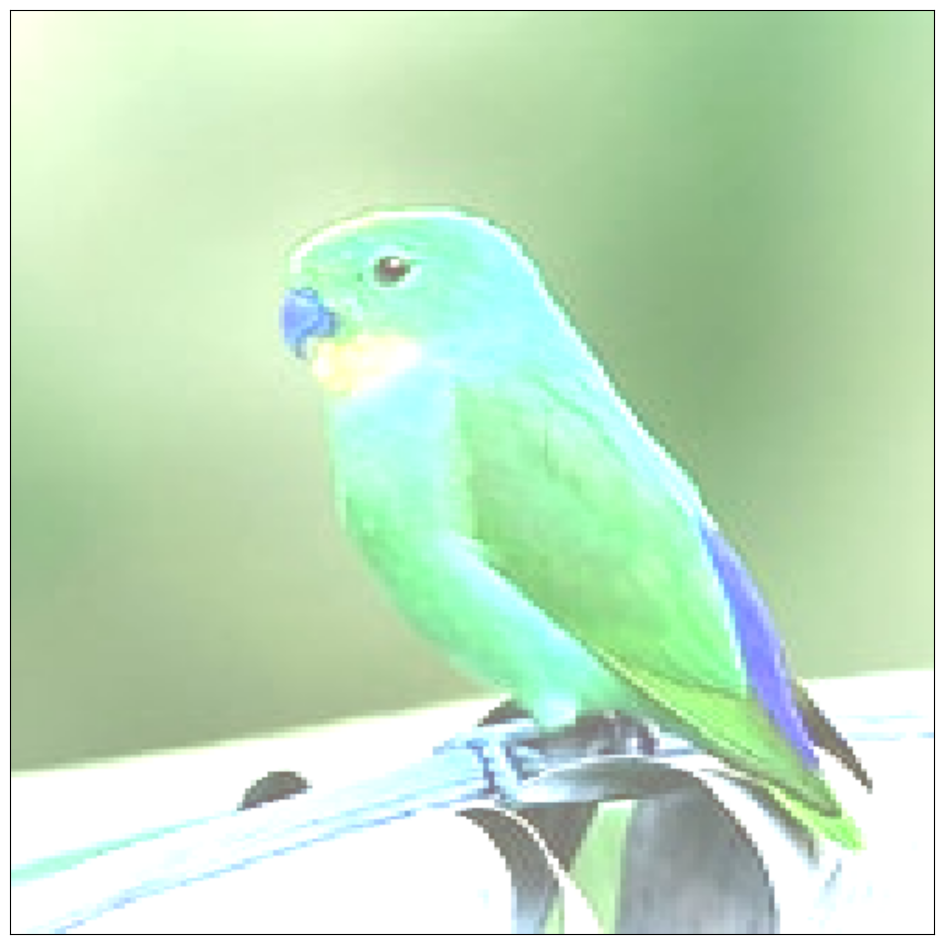

In [7]:
content_img = load_and_process_image(content_path)
display_image(content_img)

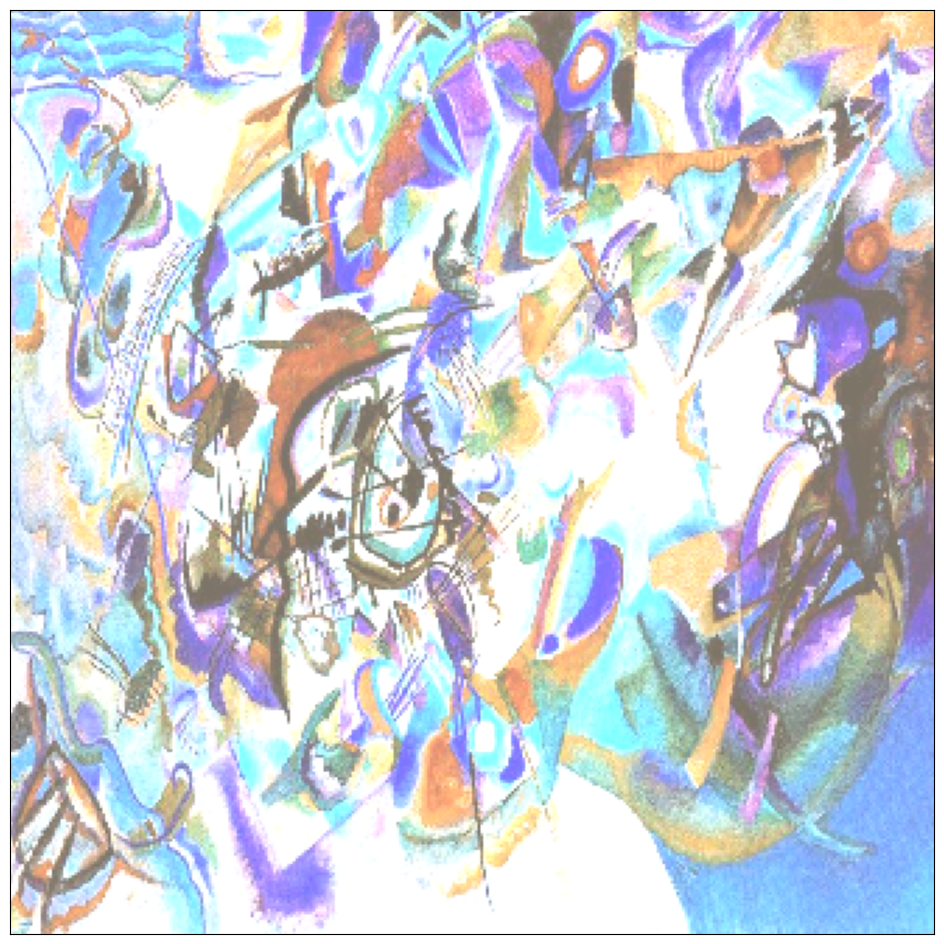

In [8]:
base_model = ConvNeXtTiny(include_top=False, weights="imagenet", input_shape=(224, 224, 3))
style_img = load_and_process_image(style_path)
display_image(style_img)

In [9]:
model = ConvNeXtTiny(include_top=False,
                          weights="imagenet")


model.trainable = False
model.summary()

Model: "convnext_tiny"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, None,      │          0 │ input_layer_5[0]… │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, None,      │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, None,      │          0 │ convnext_tiny_st… │
│                     │ None, 96)         │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ add_18[0][0]      │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st

 Total params: 27,820,128 (106.13 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27,820,128 (106.13 MB)

In [10]:

# Choose from model.summary() or layer names
style_layers = [
    'convnext_tiny_stage_0_block_2_pointwise_conv_2',
    'convnext_tiny_stage_1_block_0_pointwise_conv_2',
    'convnext_tiny_stage_2_block_3_pointwise_conv_2'
]

content_layer = 'convnext_tiny_stage_3_block_2_pointwise_conv_2'

content_model = Model(inputs = model.input,
                      outputs = model.get_layer(content_layer).output)

content_model.summary()
style_models = [Model(inputs=model.input,
                      outputs=model.get_layer(layer).output)for layer in style_layers]

Model: "functional_8"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer_5       │ (None, None,      │          0 │ -                 │
│ (InputLayer)        │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_pres… │ (None, None,      │          0 │ input_layer_5[0]… │
│ (Normalization)     │ None, 3)          │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stem  │ (None, None,      │      4,896 │ convnext_tiny_pr… │
│ (Sequential)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ convnext_tiny_st… │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st… │
│ (LayerScale)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add_18 (Add)        │ (None, None,      │          0 │ convnext_tiny_st… │
│                     │ None, 96)         │            │ convnext_tiny_st… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │      4,800 │ add_18[0][0]      │
│ (Conv2D)            │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │        192 │ convnext_tiny_st… │
│ (LayerNormalizatio… │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     37,248 │ convnext_tiny_st… │
│ (Dense)             │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │          0 │ convnext_tiny_st… │
│ (Activation)        │ None, 384)        │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │     36,960 │ convnext_tiny_st… │
│ (Dense)             │ None, 96)         │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ convnext_tiny_stag… │ (None, None,      │         96 │ convnext_tiny_st

 Total params: 27,817,824 (106.12 MB)

 Trainable params: 0 (0.00 B)

 Non-trainable params: 27,817,824 (106.12 MB)

In [11]:
def content_loss(content, generated):
    a_C = content_model(content)
    a_G = content_model(generated)
    loss = tf.reduce_mean(tf.square(a_C - a_G))
    return loss
def gram_matrix(A):
    channels = int(A.shape[-1])
    a = tf.reshape(A, [-1, channels])
    n = tf.shape(a)[0]
    gram = tf.matmul(a,a,transpose_a = True)
    return gram/tf.cast(n, tf.float32)

weight_of_layer =  1./len(style_layers)

def style_cost(style, generated):
    J_style = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_generated - gram_a_style ))
        J_style += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_style

def content_cost(style, generated):
    J_content = 0

    for style_model in style_models:
        a_style = style_model(style)
        a_generated = style_model(generated)
        gram_a_style = gram_matrix(a_style)
        gram_a_generated = gram_matrix(a_generated)
        content_cost = tf.reduce_mean(tf.square(gram_a_style - gram_a_generated))
        J_content += content_cost + weight_of_layer # bisa di ganti pake "*" instead of "+"

    return J_content

In [12]:
import math
import time
import tensorflow as tf

generated_images = []

def save_checkpoint(generated, iteration, path="checkpoint.npz"):
    np.savez(path, generated=generated.numpy(), iteration=iteration)

def load_checkpoint(path="checkpoint.npz"):
    data = np.load(path)
    return tf.Variable(data["generated"], dtype=tf.float32), int(data["iteration"])

def training_loop(content_path, style_path, iterations, start_iter=0, a=10, b=1000, checkpoint_path="checkpoint.npz"):
    content = load_and_process_image(content_path)
    style = load_and_process_image(style_path)

    # Load previous checkpoint if available
    if start_iter > 0 and os.path.exists(checkpoint_path):
        generated, start_iter = load_checkpoint(checkpoint_path)
        print(f"Resuming from iteration {start_iter}")
    else:
        generated = tf.Variable(content, dtype=tf.float32)

    opt = tf.keras.optimizers.Adam(learning_rate=0.7)
    best_cost = math.inf
    best_image = None

    for i in range(start_iter + 1, start_iter + iterations + 1):
        start_time_cpu = time.process_time()
        start_time_wall = time.time()

        with tf.GradientTape() as tape:
            J_content = content_cost(content, generated)
            J_style = style_cost(style, generated)
            J_total = a * J_content + b * J_style

        grads = tape.gradient(J_total, generated)
        opt.apply_gradients([(grads, generated)])

        end_time_cpu = time.process_time()
        end_time_wall = time.time()
        cpu_time = end_time_cpu - start_time_cpu
        wall_time = end_time_wall - start_time_wall

        if J_total < best_cost:
            best_cost = J_total
            best_image = generated.numpy()

        print(f"Iteration: {i}")
        print(f"CPU Time: {cpu_time * 1e6:.2f} µs, Wall Time: {wall_time * 1e6:.2f} µs")
        print(f"Total Loss: {J_total:.4e}")

        if i % 20 == 0:
            print(f"Saving checkpoint at iteration {i}")
            generated_images.append(generated.numpy())
            save_checkpoint(generated, i, path=checkpoint_path)

    return best_image



In [13]:
final_image = training_loop(content_path, style_path, iterations = 100)

Iteration: 1
CPU Time: 17926481.92 µs, Wall Time: 19843765.26 µs
Total Loss: 1.5626e+03
Iteration: 2
CPU Time: 14641895.04 µs, Wall Time: 14601133.35 µs
Total Loss: 1.4369e+03
Iteration: 3
CPU Time: 14585385.55 µs, Wall Time: 14563626.29 µs
Total Loss: 1.3525e+03
Iteration: 4
CPU Time: 15344690.54 µs, Wall Time: 15365861.89 µs
Total Loss: 1.3112e+03
Iteration: 5
CPU Time: 14622066.38 µs, Wall Time: 14617727.04 µs
Total Loss: 1.2827e+03
Iteration: 6
CPU Time: 14602328.13 µs, Wall Time: 14578712.94 µs
Total Loss: 1.2610e+03
Iteration: 7
CPU Time: 15374291.88 µs, Wall Time: 15394592.76 µs
Total Loss: 1.2436e+03
Iteration: 8
CPU Time: 15220213.85 µs, Wall Time: 15233758.93 µs
Total Loss: 1.2291e+03
Iteration: 9
CPU Time: 14833633.44 µs, Wall Time: 14840483.90 µs
Total Loss: 1.2169e+03
Iteration: 10
CPU Time: 14639676.75 µs, Wall Time: 14618906.97 µs
Total Loss: 1.2062e+03
Iteration: 11
CPU Time: 14649961.43 µs, Wall Time: 14633441.45 µs
Total Loss: 1.1966e+03
Iteration: 12
CPU Time: 155794

In [14]:
# Tampilkan dengan matplotlib
import matplotlib.pyplot as plt

def display_image(img_array):
    if len(img_array.shape) == 4:
        img_array = np.squeeze(img_array, axis=0)
    img = deprocess(img_array)
    plt.imshow(img)
    plt.axis('off')
    plt.show()


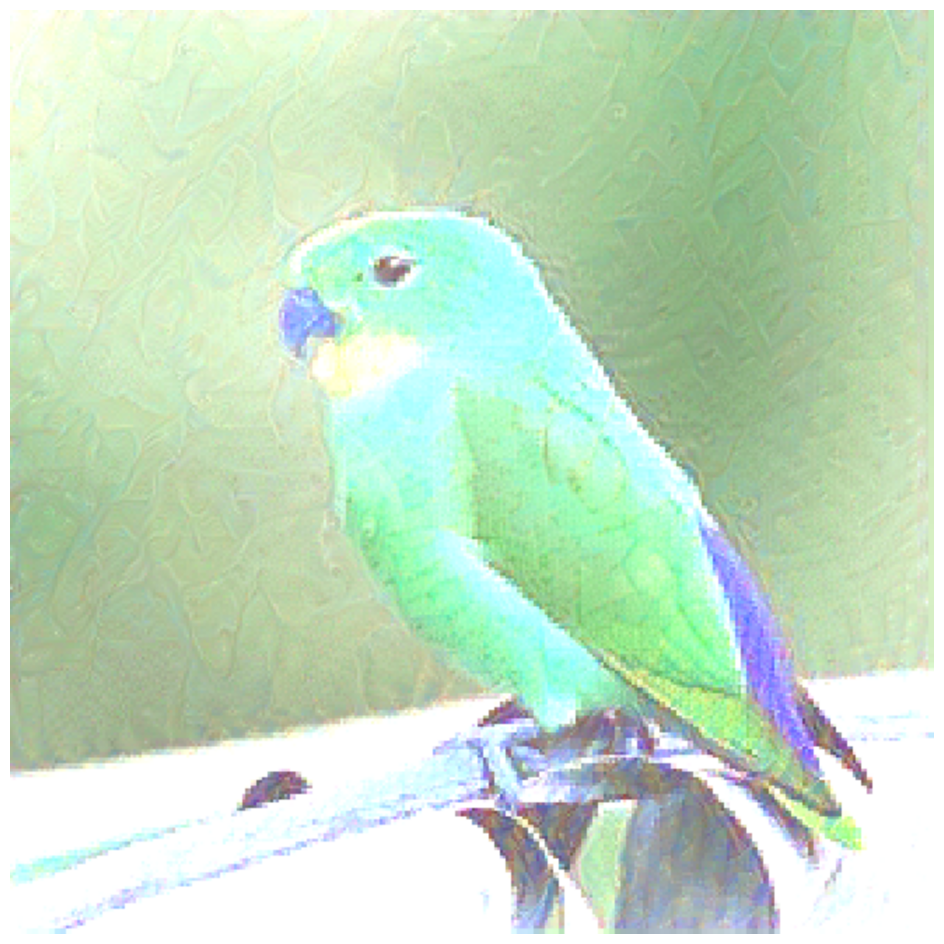

In [15]:
last_generated = generated_images[-1]

# Ayo kita lihat hasil terakhir
display_image(last_generated)
